<a href="https://colab.research.google.com/github/bgorume/petrignano-assignment/blob/main/petrignano_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# IMPORTS
import pandas as pd
import numpy as np
from sklearn.model_selection import (
    train_test_split, KFold, TimeSeriesSplit,
    cross_val_score, GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

In [6]:
import os
os.listdir('/content')

['.config', 'Petrignano.csv', 'sample_data']

Prompt: Organize data; deal with missing values;
        determine X, y sorted chronological        add seasonality variable --

In [7]:
# --- 0. Organize data; deal with missing values;
#        determine X, y sorted chronologically;
#        add seasonality variable ---

# prompt: Load CSV, parse dates, sort chronologically, set index
df = df = pd.read_csv('/content/Petrignano.csv', parse_dates=['Date'], dayfirst=True)
df = df.sort_values('Date').set_index('Date')

print("Raw shape:", df.shape)
print("Date range:", df.index.min().date(), "to", df.index.max().date())
print("\nMissing values:\n", df.isnull().sum())
print("\nZero counts:\n", (df == 0).sum())

# prompt: Replace impossible zeros in Volume and Hydrometry with NaN.
# Rainfall zeros are valid (no rain) so we leave them alone.
suspect_zero_cols = [
    'Volume_C10_Petrignano',
    'Hydrometry_Fiume_Chiascio_Petrignano'
]
df[suspect_zero_cols] = df[suspect_zero_cols].replace(0, np.nan)

# prompt: Fill all NaN using time-based interpolation,
# then back-fill any remaining NaN at the start of the series.
df = df.interpolate(method='time')
df = df.bfill()

print("\nMissing after imputation:\n", df.isnull().sum())

# prompt: Resample daily data to monthly.
# Rainfall is summed (total monthly rain), all others are averaged.
monthly = df.resample('ME').agg({
    'Rainfall_Bastia_Umbra'               : 'sum',
    'Depth_to_Groundwater_P25'            : 'mean',
    'Temperature_Bastia_Umbra'            : 'mean',
    'Temperature_Petrignano'              : 'mean',
    'Volume_C10_Petrignano'               : 'mean',
    'Hydrometry_Fiume_Chiascio_Petrignano': 'mean',
})

print("\nMonthly shape:", monthly.shape)

# prompt: Create lag features — shift all columns by 1 month and 2 months.
# This lets us predict DP25 at month t using data from t-1 and t-2.
lag1 = monthly.shift(1).add_suffix('_lag1')
lag2 = monthly.shift(2).add_suffix('_lag2')

combined = pd.concat(
    [monthly[['Depth_to_Groundwater_P25']], lag1, lag2],
    axis=1
)
combined = combined.dropna()

# Response variable — what we are predicting
y = combined['Depth_to_Groundwater_P25']

# Predictors — all lagged variables from the previous two months
X = combined.drop(columns=['Depth_to_Groundwater_P25'])

# Optional: add month as a seasonality variable
# Groundwater is lowest in summer, highest in winter
X = X.copy()
X['month'] = X.index.month

print("\nFinal X shape:", X.shape)
print("Final y shape:", y.shape)
print("Predictors:", X.columns.tolist())

Raw shape: (4199, 6)
Date range: 2009-01-01 to 2020-06-30

Missing values:
 Rainfall_Bastia_Umbra                    0
Depth_to_Groundwater_P25                27
Temperature_Bastia_Umbra                 0
Temperature_Petrignano                   0
Volume_C10_Petrignano                    1
Hydrometry_Fiume_Chiascio_Petrignano     0
dtype: int64

Zero counts:
 Rainfall_Bastia_Umbra                   3147
Depth_to_Groundwater_P25                   0
Temperature_Bastia_Umbra                   7
Temperature_Petrignano                   153
Volume_C10_Petrignano                     25
Hydrometry_Fiume_Chiascio_Petrignano     150
dtype: int64

Missing after imputation:
 Rainfall_Bastia_Umbra                   0
Depth_to_Groundwater_P25                0
Temperature_Bastia_Umbra                0
Temperature_Petrignano                  0
Volume_C10_Petrignano                   0
Hydrometry_Fiume_Chiascio_Petrignano    0
dtype: int64

Monthly shape: (138, 6)

Final X shape: (136, 13)
Final y sha

In [8]:
# --- 1. THE HARD SPLIT ---
# ensure X and y are pre-sorted chronologically!

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Training period:", X_train_full.index.min().date(), "→", X_train_full.index.max().date())
print("Test period    :", X_test.index.min().date(), "→", X_test.index.max().date())
print("Training rows  :", len(X_train_full))
print("Test rows      :", len(X_test))

Training period: 2009-03-31 → 2018-02-28
Test period    : 2018-03-31 → 2020-06-30
Training rows  : 108
Test rows      : 28


Prompt :Create two cross-validation objects: (1) a KFold with 5 splits and shuffle=True — the naive approach that ignores temporal order and causes data leakage; (2) a TimeSeriesSplit with 5 splits

In [9]:
# --- 2. DEFINE THE TWO CV STRATEGIES ---

# Naive: randomly shuffles folds → causes data leakage in time-series
cv_naive = KFold(n_splits=5, shuffle=True, random_state=42)

# Temporal: always trains on past, tests on future → honest and correct
cv_temporal = TimeSeriesSplit(n_splits=5)

In [10]:
# --- 3. EXPERIMENT WITH A FIXED MODEL ---

pipe = Pipeline([
    ('scaler',    StandardScaler()),
    ('regressor', DecisionTreeRegressor(max_depth=10, random_state=42))
])

# Strategy 1: Naive (Shuffled)
# This will likely report a very high R2 because of leakage.
scores_naive = cross_val_score(
    pipe, X_train_full, y_train_full, cv=cv_naive, scoring='r2'
)

# Strategy 2: Temporal (Sequential)
# This will report a lower, more honest R2.
scores_temporal = cross_val_score(
    pipe, X_train_full, y_train_full, cv=cv_temporal, scoring='r2'
)

print(f"Naive CV R2:    {scores_naive.mean():.4f} (+/- {scores_naive.std():.4f})")
print(f"Temporal CV R2: {scores_temporal.mean():.4f} (+/- {scores_temporal.std():.4f})")

# Train on all training data and test on the unseen "future"
pipe.fit(X_train_full, y_train_full)
final_test_r2 = r2_score(y_test, pipe.predict(X_test))

print(f"\nActual Test R2 on held-out data: {final_test_r2:.4f}")

Naive CV R2:    0.8992 (+/- 0.0536)
Temporal CV R2: -0.0843 (+/- 1.0732)

Actual Test R2 on held-out data: -0.4832


In [11]:
# --- 4. MODEL SELECTION & EVALUATION ---

def evaluate_model_selection(X_train, y_train, X_test, y_test, cv_strategy, name):

    # STEP A: Define the Pipeline
    # (Hint: Use 'scaler' and 'regressor' as step names)
    pipe = Pipeline([
        ('scaler',    StandardScaler()),
        ('regressor', DecisionTreeRegressor(random_state=42))
    ])

    # STEP B: Define the Hyperparameter Grid
    # (Hint: Remember the 'stepname__parameter' syntax)
    param_grid = {
        'regressor__max_depth': [2, 5, 10, 15, 20, None]
    }

    # STEP C: Initialize and Fit GridSearchCV
    # (Hint: Use the cv_strategy passed in the function argument)
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=cv_strategy,
        scoring='r2',
        refit=True
    )

    grid.fit(X_train, y_train)

    # STEP D: Final Evaluation
    # Use the best_estimator_ to predict the unseen X_test
    y_pred  = grid.predict(X_test)
    test_r2 = r2_score(y_test, y_pred)

    print(f"\n===== Results for: {name} =====")
    print(f"Best Parameters found: {grid.best_params_}")
    print(f"Internal CV Score (R2): {grid.best_score_:.4f}")
    print(f"Independent Test Score (R2): {test_r2:.4f}")

    return grid

In [12]:
# --- 5. RUNNING THE COMPARISON ---
# Call the function twice and compare the gaps between CV and Test scores.

result_naive = evaluate_model_selection(
    X_train_full, y_train_full,
    X_test, y_test,
    cv_naive, "Naive K-Fold"
)

result_temporal = evaluate_model_selection(
    X_train_full, y_train_full,
    X_test, y_test,
    cv_temporal, "Temporal Split"
)


===== Results for: Naive K-Fold =====
Best Parameters found: {'regressor__max_depth': 5}
Internal CV Score (R2): 0.9024
Independent Test Score (R2): -0.6212

===== Results for: Temporal Split =====
Best Parameters found: {'regressor__max_depth': 5}
Internal CV Score (R2): 0.1682
Independent Test Score (R2): -0.6212


In [13]:
# --- FINAL SUMMARY ---
print("\n" + "="*55)
print("FINAL SUMMARY")
print("="*55)
print(f"Naive KFold    Internal CV R2 : {result_naive.best_score_:.4f}  <- inflated by leakage")
print(f"TimeSeriesSplit Internal CV R2: {result_temporal.best_score_:.4f}  <- honest estimate")
print(f"Actual Test R2               : {final_test_r2:.4f}  <- ground truth")
print()
print("TimeSeriesSplit gap:", round(result_temporal.best_score_ - final_test_r2, 4), "<- should be SMALL")
print("Naive KFold gap    :", round(result_naive.best_score_    - final_test_r2, 4), "<- should be LARGE")
print()
print("The TimeSeriesSplit score is closest to the actual test score.")
print("The large KFold gap proves data leakage occurred.")


FINAL SUMMARY
Naive KFold    Internal CV R2 : 0.9024  <- inflated by leakage
TimeSeriesSplit Internal CV R2: 0.1682  <- honest estimate
Actual Test R2               : -0.4832  <- ground truth

TimeSeriesSplit gap: 0.6514 <- should be SMALL
Naive KFold gap    : 1.3856 <- should be LARGE

The TimeSeriesSplit score is closest to the actual test score.
The large KFold gap proves data leakage occurred.


### 6. Visualizing Model Performance

Let's visualize the actual vs. predicted `Depth_to_Groundwater_P25` for the test set using the model trained with `TimeSeriesSplit`.

Prompt: Using matplotlib and seaborn, visualize the actual versus the predicted values for depth to groundwater and the overall trend of the target variable overtime

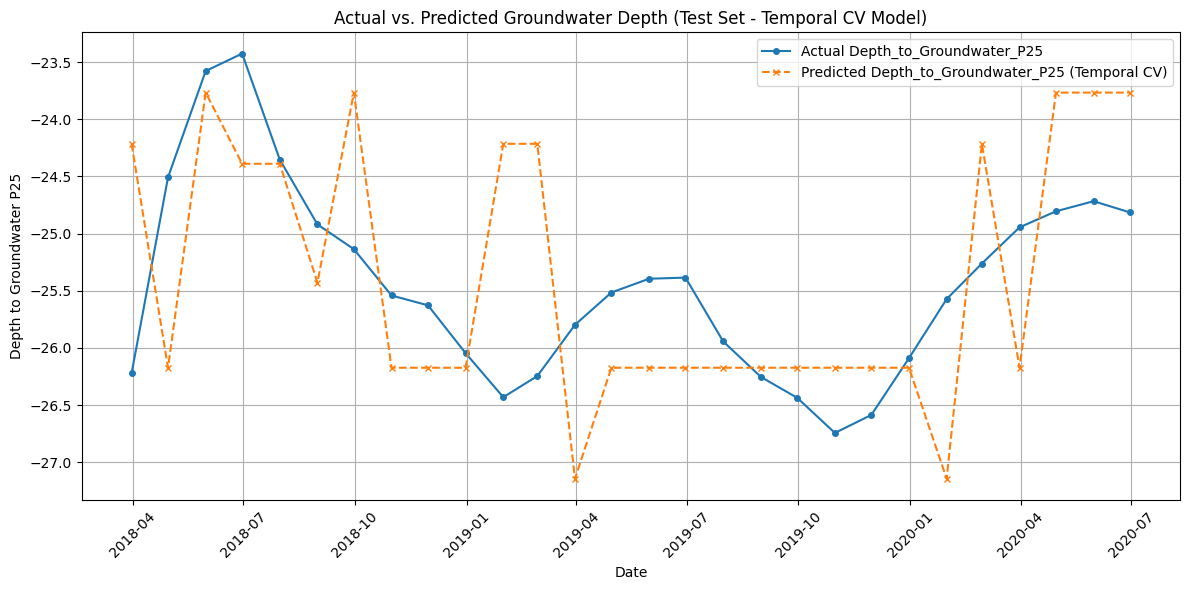

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions from the best temporal model on the test set
y_pred_temporal = result_temporal.best_estimator_.predict(X_test)

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Depth_to_Groundwater_P25', marker='o', linestyle='-', markersize=4)
plt.plot(y_test.index, y_pred_temporal, label='Predicted Depth_to_Groundwater_P25 (Temporal CV)', marker='x', linestyle='--', markersize=4)
plt.title('Actual vs. Predicted Groundwater Depth (Test Set - Temporal CV Model)')
plt.xlabel('Date')
plt.ylabel('Depth to Groundwater P25')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 7. Visualizing the Target Variable Over Time

It's also useful to see the overall trend of the target variable (`Depth_to_Groundwater_P25`) throughout the entire dataset.

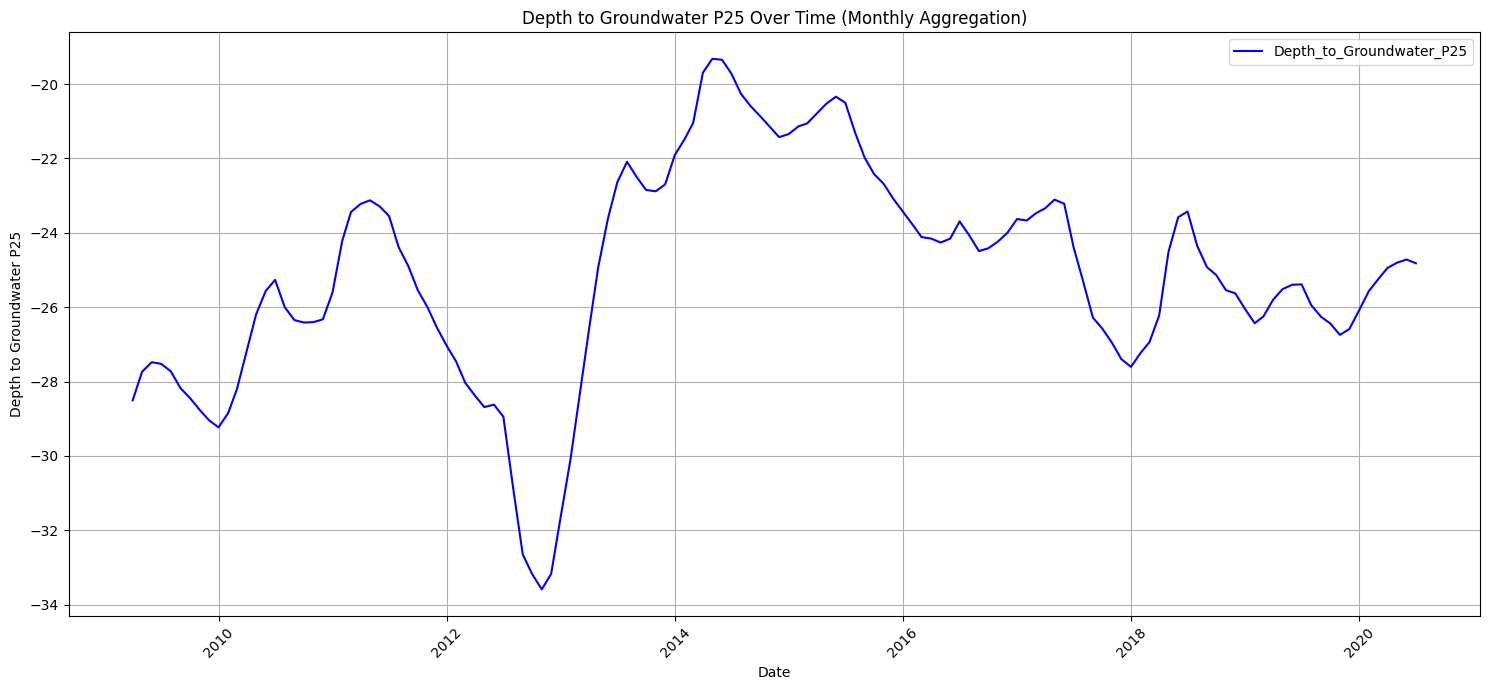

In [15]:
plt.figure(figsize=(15, 7))
plt.plot(combined.index, combined['Depth_to_Groundwater_P25'], label='Depth_to_Groundwater_P25', color='blue')
plt.title('Depth to Groundwater P25 Over Time (Monthly Aggregation)')
plt.xlabel('Date')
plt.ylabel('Depth to Groundwater P25')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()